# Convolve 3.0

## Problem Statement:

You have been provided with a random sample of **96,806** Credit Card details in  
“Dev_data_to_be_shared.zip”, along with a flag **(bad_flag)** henceforth known as “development
data”.<br>
This is a historical snapshot of the Credit Card portfolio of Bank A. <br>
**Credit Cards that have actually defaulted have bad_flag = 1.**<br>
You have also been provided with several independent variables.<br>

These include: <br>
- On us attributes like credit limit (varables with names starting with onus_attributes)
- Transaction level attributes like number of transactions / rupee value transactions on
various kinds of merchants (variables with names starting with transaction_attribute)
- Bureau tradeline level attributes (like product holdings, historical delinquencies) – variables
starting with bureau
- Bureau enquiry level attributes (like PL enquiries in the last 3 months etc) – variables
starting with bureau_enquiry.

You have also been provided with another random sample of 41,792 Credit Card details in “validation_data_to_be_shared.zip” with the same set of input variables, but without “bad_flag”. <br>
This will be referred to going forward as “validation data”.

**Your objective is to develop the **Behaviour Score** for Bank A.**

Bank A issues Credit Cards to eligible customers. The Bank deploys advanced ML models and frameworks to decide on eligibility, limit, and interest rate assignment. <br>
The models and frameworks are optimized to manage early risk and ensure profitability.  <br>
The Bank has now decided to build a robust risk management framework for its existing Credit Card customers, irrespective of when they were acquired. <br>
To enable this, the Bank has decided to create a **“Behaviour Score”**. A Behaviour Score is a predictive model. It is developed on a base of customers whose Credit Cards are **open** and are **not past due**. <br>
<br>
The model predicts the probability of customers defaulting on the Credit Cards going forward. <br>
This model will then be used for several portfolio risk management activities

IMPORTS

In [39]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

RANDOM_STATE = 42

LOAD DEVELOPMENT DATA

In [40]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:
dev_path = "/content/drive/MyDrive/CONVOLVE 3.0 - CREDIT RISK/Dev_data_to_be_shared.csv"

dev_df = pd.read_csv(dev_path)

print("Shape:", dev_df.shape)
display(dev_df.head())

Shape: (96806, 1216)


,account_number,bad_flag,onus_attribute_1,transaction_attribute_1,transaction_attribute_2,transaction_attribute_3,transaction_attribute_4,transaction_attribute_5,transaction_attribute_6,transaction_attribute_7,...,bureau_enquiry_47,bureau_enquiry_48,bureau_enquiry_49,bureau_enquiry_50,onus_attribute_43,onus_attribute_44,onus_attribute_45,onus_attribute_46,onus_attribute_47,onus_attribute_48
0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2,0,221000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,0,25000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN
3,4,0,86000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN
4,5,0,215000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN


TARGET DISTRIBUTION

In [42]:
print(dev_df["bad_flag"].value_counts())
print()

print("Target proportions:")
print(dev_df["bad_flag"].value_counts(normalize=True))

bad_flag
0    95434
1     1372
Name: count, dtype: int64

Target proportions:
bad_flag
0    0.985827
1    0.014173
Name: proportion, dtype: float64


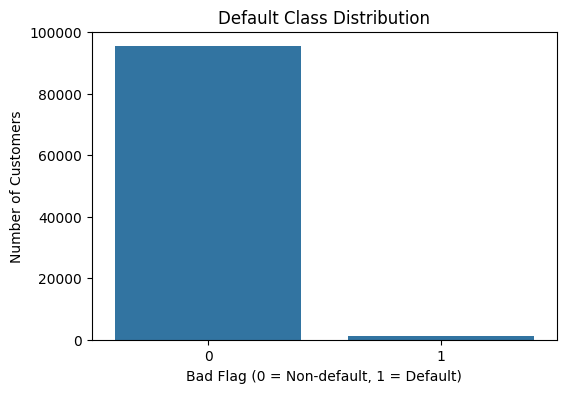

In [43]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=dev_df,
    x="bad_flag"
)

plt.title("Default Class Distribution")
plt.xlabel("Bad Flag (0 = Non-default, 1 = Default)")
plt.ylabel("Number of Customers")
plt.show()

REMOVING EMPTY COLUMNS

In [44]:
empty_columns = dev_df.columns[
    dev_df.isna().all()
]

print("Completely empty columns:", len(empty_columns))

dev_df = dev_df.drop(columns=empty_columns)

print("New shape:", dev_df.shape)

Completely empty columns: 2
New shape: (96806, 1214)


SEPARATE FEATURES AND TARGET

In [45]:
X = dev_df.drop(columns=["bad_flag"])
y = dev_df["bad_flag"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (96806, 1213)
y shape: (96806,)


IDENTIFY FEATURE FAMILIES

In [46]:
onus_cols = [
    c for c in X.columns
    if "onus_attribute" in c
]

transaction_cols = [
    c for c in X.columns
    if "transaction_attribute" in c
]

bureau_enquiry_cols = [
    c for c in X.columns
    if "bureau_enquiry" in c
]

bureau_cols = [
    c for c in X.columns
    if "bureau" in c and "bureau_enquiry" not in c
]

print("On-us features:", len(onus_cols))
print("Transaction features:", len(transaction_cols))
print("Bureau features:", len(bureau_cols))
print("Bureau enquiry features:", len(bureau_enquiry_cols))

print(
    "Total identified:",
    len(onus_cols)
    + len(transaction_cols)
    + len(bureau_cols)
    + len(bureau_enquiry_cols)
)

On-us features: 48
Transaction features: 664
Bureau features: 450
Bureau enquiry features: 50
Total identified: 1212


CHECK UNCLASSIFIED FEATURES

In [47]:
identified_cols = (
    onus_cols
    + transaction_cols
    + bureau_cols
    + bureau_enquiry_cols
)

unclassified_cols = [
    c for c in X.columns
    if c not in identified_cols
]

print("Unclassified columns:", len(unclassified_cols))
print(unclassified_cols[:30])

Unclassified columns: 1
['account_number']


In [48]:
# Remove customer identifier from modelling features
X = X.drop(columns=["account_number"])

print("Final feature matrix:", X.shape)

Final feature matrix: (96806, 1212)


In [49]:
onus_cols = [
    c for c in X.columns
    if "onus_attribute" in c
]

transaction_cols = [
    c for c in X.columns
    if "transaction_attribute" in c
]

bureau_enquiry_cols = [
    c for c in X.columns
    if "bureau_enquiry" in c
]

bureau_cols = [
    c for c in X.columns
    if "bureau" in c and "bureau_enquiry" not in c
]

print("On-us:", len(onus_cols))
print("Transaction:", len(transaction_cols))
print("Bureau:", len(bureau_cols))
print("Bureau enquiry:", len(bureau_enquiry_cols))

print(
    "Total:",
    len(onus_cols)
    + len(transaction_cols)
    + len(bureau_cols)
    + len(bureau_enquiry_cols)
)

On-us: 48
Transaction: 664
Bureau: 450
Bureau enquiry: 50
Total: 1212


STRATIFIED TRAIN / TEST SPLIT

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (77444, 1212)
Test shape: (19362, 1212)

Train target distribution:
bad_flag
0    0.985822
1    0.014178
Name: proportion, dtype: float64

Test target distribution:
bad_flag
0    0.985849
1    0.014151
Name: proportion, dtype: float64


In [51]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTrain defaults:", y_train.sum())
print("Test defaults :", y_test.sum())

X_train: (77444, 1212)
X_test : (19362, 1212)
y_train: (77444,)
y_test : (19362,)

Train defaults: 1098
Test defaults : 274


LEAKAGE-SAFE FAMILY PREPROCESSING

In [52]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


def fit_family_preprocessor(X_train_family, n_components=5):
    """
    Fit preprocessing for one feature family using TRAINING DATA ONLY.

    Pipeline:
        1. Mean imputation
        2. Standardization
        3. PCA

    Returns:
        imputer
        scaler
        pca
        transformed training data
    """

    # --------------------------------------------------------
    # 1. IMPUTATION
    # --------------------------------------------------------
    imputer = SimpleImputer(strategy="mean")

    X_train_imputed = imputer.fit_transform(
        X_train_family
    )

    # --------------------------------------------------------
    # 2. STANDARDIZATION
    # --------------------------------------------------------
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train_imputed
    )

    # --------------------------------------------------------
    # 3. PCA
    # --------------------------------------------------------
    pca = PCA(
        n_components=n_components,
        random_state=RANDOM_STATE
    )

    X_train_pca = pca.fit_transform(
        X_train_scaled
    )

    return (
        imputer,
        scaler,
        pca,
        X_train_pca
    )

FIT PREPROCESSORS FOR ALL FOUR FAMILIES

In [53]:
family_columns = {
    "onus": onus_cols,
    "transaction": transaction_cols,
    "bureau": bureau_cols,
    "bureau_enquiry": bureau_enquiry_cols
}

preprocessors = {}
train_pca_arrays = {}

for family, columns in family_columns.items():

    print("=" * 60)
    print(f"FAMILY: {family.upper()}")
    print(f"Original features: {len(columns)}")

    (
        imputer,
        scaler,
        pca,
        X_train_pca
    ) = fit_family_preprocessor(
        X_train[columns],
        n_components=5
    )

    # Store fitted objects
    preprocessors[family] = {
        "imputer": imputer,
        "scaler": scaler,
        "pca": pca
    }

    # Store transformed training data
    train_pca_arrays[family] = X_train_pca

    print(
        f"Reduced features: "
        f"{X_train_pca.shape[1]}"
    )

    print(
        f"Explained variance: "
        f"{pca.explained_variance_ratio_.sum():.2%}"
    )

    print()

FAMILY: ONUS
Original features: 48
Reduced features: 5
Explained variance: 53.45%

FAMILY: TRANSACTION
Original features: 664
Reduced features: 5
Explained variance: 13.32%

FAMILY: BUREAU
Original features: 450
Reduced features: 5
Explained variance: 31.54%

FAMILY: BUREAU_ENQUIRY
Original features: 50
Reduced features: 5
Explained variance: 69.31%



PCA EXPLAINED VARIANCE ANALYSIS

In [54]:
pca_analysis = {}

for family, columns in family_columns.items():

    print(f"Analyzing PCA for: {family}")

    # Impute
    imputer = SimpleImputer(strategy="mean")
    X_imputed = imputer.fit_transform(
        X_train[columns]
    )

    # Scale
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(
        X_imputed
    )

    # Fit PCA with enough components to analyze
    max_components = min(
        20,
        X_scaled.shape[0],
        X_scaled.shape[1]
    )

    pca = PCA(
        n_components=max_components,
        random_state=RANDOM_STATE
    )

    pca.fit(X_scaled)

    cumulative_variance = np.cumsum(
        pca.explained_variance_ratio_
    )

    pca_analysis[family] = {
        "imputer": imputer,
        "scaler": scaler,
        "pca": pca,
        "explained_variance": pca.explained_variance_ratio_,
        "cumulative_variance": cumulative_variance
    }

    print(
        f"Variance explained by first 5 PCs: "
        f"{cumulative_variance[4]:.2%}"
    )

Analyzing PCA for: onus
Variance explained by first 5 PCs: 53.45%
Analyzing PCA for: transaction
Variance explained by first 5 PCs: 13.32%
Analyzing PCA for: bureau
Variance explained by first 5 PCs: 31.54%
Analyzing PCA for: bureau_enquiry
Variance explained by first 5 PCs: 69.31%


CUMULATIVE EXPLAINED VARIANCE

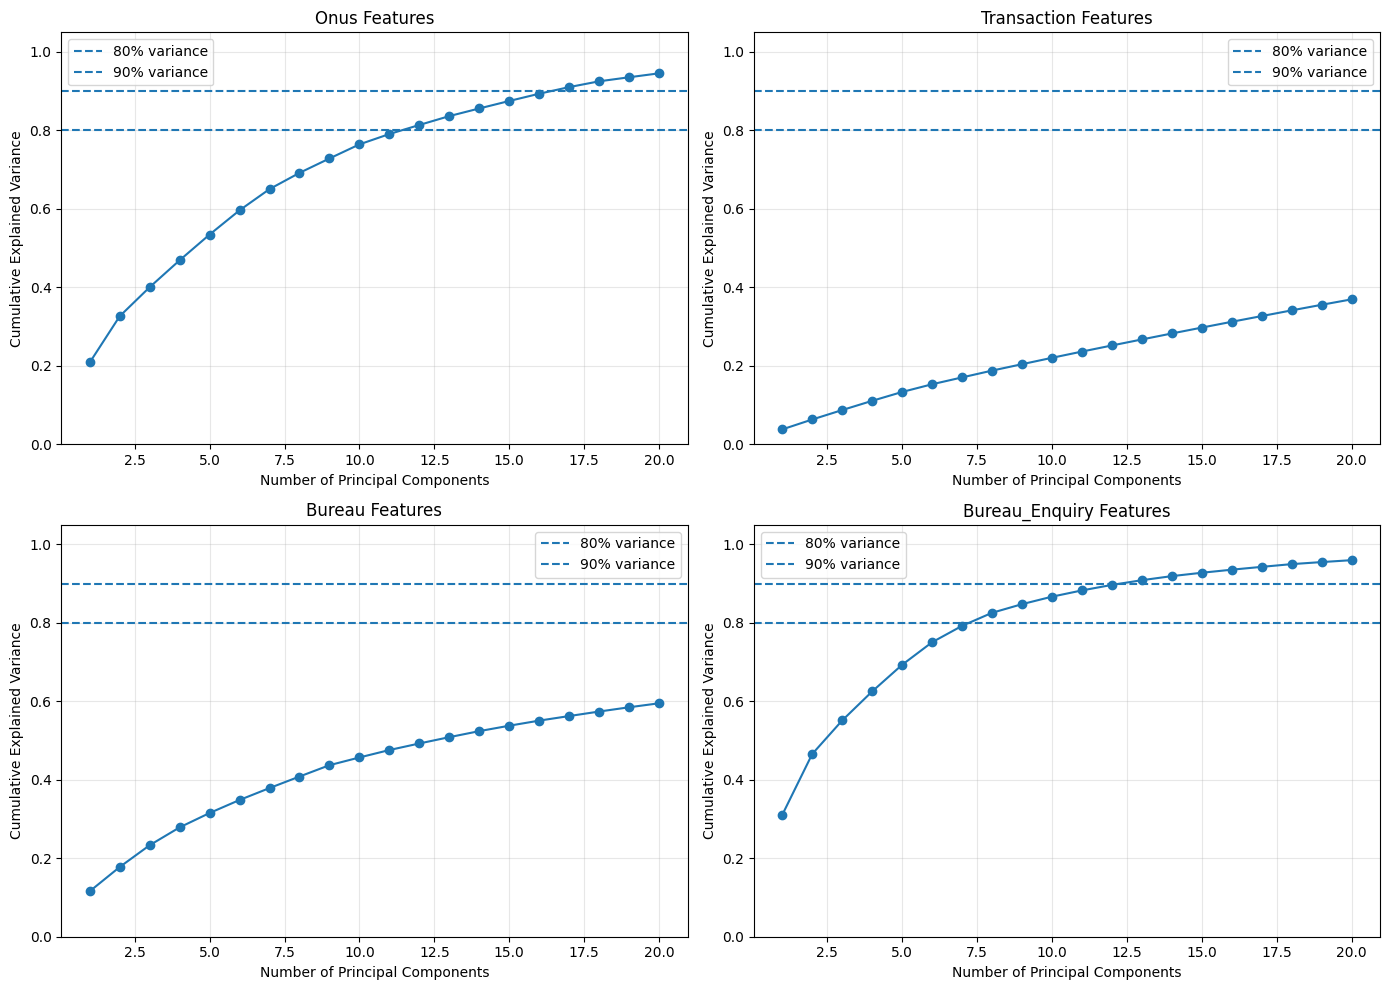

In [55]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10)
)

axes = axes.flatten()

for ax, (family, results) in zip(
    axes,
    pca_analysis.items()
):

    cumulative_variance = results["cumulative_variance"]

    components = np.arange(
        1,
        len(cumulative_variance) + 1
    )

    ax.plot(
        components,
        cumulative_variance,
        marker="o"
    )

    ax.axhline(
        0.80,
        linestyle="--",
        label="80% variance"
    )

    ax.axhline(
        0.90,
        linestyle="--",
        label="90% variance"
    )

    ax.set_title(
        f"{family.title()} Features"
    )

    ax.set_xlabel(
        "Number of Principal Components"
    )

    ax.set_ylabel(
        "Cumulative Explained Variance"
    )

    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

TRANSFORM TEST DATA USING TRAINED PREPROCESSORS

In [56]:
def transform_family(
    X_family,
    imputer,
    scaler,
    pca
):
    """
    Transform new data using preprocessing
    parameters learned from training data.
    """

    # Apply TRAINING imputer
    X_imputed = imputer.transform(
        X_family
    )

    # Apply TRAINING scaler
    X_scaled = scaler.transform(
        X_imputed
    )

    # Apply TRAINING PCA
    X_pca = pca.transform(
        X_scaled
    )

    return X_pca

In [57]:
test_pca_arrays = {}

for family, columns in family_columns.items():

    processor = preprocessors[family]

    X_test_pca = transform_family(
        X_test[columns],
        processor["imputer"],
        processor["scaler"],
        processor["pca"]
    )

    test_pca_arrays[family] = X_test_pca

    print(
        f"{family}: "
        f"Train {train_pca_arrays[family].shape} | "
        f"Test {X_test_pca.shape}"
    )

onus: Train (77444, 5) | Test (19362, 5)
transaction: Train (77444, 5) | Test (19362, 5)
bureau: Train (77444, 5) | Test (19362, 5)
bureau_enquiry: Train (77444, 5) | Test (19362, 5)


COMBINE PCA FEATURES

In [58]:
X_train_pca = np.hstack([
    train_pca_arrays["onus"],
    train_pca_arrays["transaction"],
    train_pca_arrays["bureau"],
    train_pca_arrays["bureau_enquiry"]
])

X_test_pca = np.hstack([
    test_pca_arrays["onus"],
    test_pca_arrays["transaction"],
    test_pca_arrays["bureau"],
    test_pca_arrays["bureau_enquiry"]
])

print("X_train_pca:", X_train_pca.shape)
print("X_test_pca :", X_test_pca.shape)

X_train_pca: (77444, 20)
X_test_pca : (19362, 20)


PCA FEATURE NAMES

In [59]:
pca_feature_names = []

for family in family_columns.keys():

    for i in range(1, 6):

        pca_feature_names.append(
            f"{family}_PC{i}"
        )

print(pca_feature_names)

['onus_PC1', 'onus_PC2', 'onus_PC3', 'onus_PC4', 'onus_PC5', 'transaction_PC1', 'transaction_PC2', 'transaction_PC3', 'transaction_PC4', 'transaction_PC5', 'bureau_PC1', 'bureau_PC2', 'bureau_PC3', 'bureau_PC4', 'bureau_PC5', 'bureau_enquiry_PC1', 'bureau_enquiry_PC2', 'bureau_enquiry_PC3', 'bureau_enquiry_PC4', 'bureau_enquiry_PC5']


In [60]:
X_train_pca_df = pd.DataFrame(
    X_train_pca,
    columns=pca_feature_names,
    index=X_train.index
)

X_test_pca_df = pd.DataFrame(
    X_test_pca,
    columns=pca_feature_names,
    index=X_test.index
)

print(X_train_pca_df.shape)
print(X_test_pca_df.shape)

(77444, 20)
(19362, 20)


SANITY CHECK

In [61]:
print("Missing values in PCA training data:")
print(X_train_pca_df.isna().sum().sum())

print("\nMissing values in PCA test data:")
print(X_test_pca_df.isna().sum().sum())

print("\nTraining PCA feature statistics:")
display(
    X_train_pca_df.describe().T[
        ["mean", "std", "min", "max"]
    ]
)

Missing values in PCA training data:
0

Missing values in PCA test data:
0

Training PCA feature statistics:


,mean,std,min,max
onus_PC1,9.688719e-17,3.129187,-5.102669,27.280366
onus_PC2,-1.572582e-16,2.354548,-16.994322,9.034322
onus_PC3,-5.431554e-17,1.865400,-9.650612,83.576307
onus_PC4,-7.670236e-17,1.795653,-35.034427,8.307364
onus_PC5,3.119474e-18,1.755771,-22.571428,31.484893
transaction_PC1,-1.330364e-17,4.987039,-12.329275,548.114910
transaction_PC2,-1.013829e-16,4.074840,-150.359244,353.140741
transaction_PC3,-2.598338e-16,3.977407,-134.536958,303.599399
transaction_PC4,-1.156040e-17,3.933731,-36.273928,1079.820350
transaction_PC5,4.587461e-17,3.856028,-137.568543,37.873332


SMOTE ON TRAINING DATA ONLY

In [62]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=RANDOM_STATE,
    sampling_strategy="auto",
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_pca_df,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

print("\nBefore SMOTE shape:")
print(X_train_pca_df.shape)

print("\nAfter SMOTE shape:")

Before SMOTE:
bad_flag
0    76346
1     1098
Name: count, dtype: int64

After SMOTE:
bad_flag
0    76346
1    76346
Name: count, dtype: int64

Before SMOTE shape:
(77444, 20)

After SMOTE shape:


MODEL EVALUATION FUNCTION

In [63]:
def evaluate_model(
    model,
    X_test,
    y_test,
    model_name
):
    """
    Evaluate a binary classification model.

    Primary metrics:
        ROC-AUC
        PR-AUC

    Supporting metrics:
        Accuracy
        Precision
        Recall
        F1
    """

    # Probability of class 1
    y_prob = model.predict_proba(
        X_test
    )[:, 1]

    # Default threshold = 0.5
    y_pred = (
        y_prob >= 0.5
    ).astype(int)

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            y_prob
        ),
        "PR-AUC": average_precision_score(
            y_test,
            y_prob
        )
    }

    return results

BASELINE LOGISTIC REGRESSION

In [64]:
baseline_lr = LogisticRegression(
    max_iter=1000,
    class_weight=None,
    random_state=RANDOM_STATE
)

baseline_lr.fit(
    X_train_pca_df,
    y_train
)

baseline_lr_results = evaluate_model(
    baseline_lr,
    X_test_pca_df,
    y_test,
    "Logistic Regression - No SMOTE"
)

baseline_lr_results

{'Model': 'Logistic Regression - No SMOTE',
 'Accuracy': 0.9856936266914575,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1': 0.0,
 'ROC-AUC': np.float64(0.8079683570829842),
 'PR-AUC': np.float64(0.0640768193547383)}

LOGISTIC REGRESSION + SMOTE

In [65]:
smote_lr = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

smote_lr.fit(
    X_train_smote,
    y_train_smote
)

smote_lr_results = evaluate_model(
    smote_lr,
    X_test_pca_df,
    y_test,
    "Logistic Regression + SMOTE"
)

smote_lr_results

{'Model': 'Logistic Regression + SMOTE',
 'Accuracy': 0.7346864993285818,
 'Precision': 0.0390521327014218,
 'Recall': 0.7518248175182481,
 'F1': 0.0742476121823752,
 'ROC-AUC': np.float64(0.8079421626152558),
 'PR-AUC': np.float64(0.06104666142990216)}

RANDOM FOREST

In [69]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=10,
    class_weight=None,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(
    X_train_smote,
    y_train_smote
)

rf_results = evaluate_model(
    rf,
    X_test_pca_df,
    y_test,
    "Random Forest + SMOTE"
)

rf_results

{'Model': 'Random Forest + SMOTE',
 'Accuracy': 0.7885032537960954,
 'Precision': 0.04041375992302141,
 'Recall': 0.6131386861313869,
 'F1': 0.07582938388625593,
 'ROC-AUC': np.float64(0.7904404341627866),
 'PR-AUC': np.float64(0.058946248502903364)}

LOGISTIC REGRESSION + SMOTE

In [70]:
smote_lr = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

smote_lr.fit(
    X_train_smote,
    y_train_smote
)

smote_lr_results = evaluate_model(
    smote_lr,
    X_test_pca_df,
    y_test,
    "Logistic Regression + SMOTE"
)

print(smote_lr_results)

{'Model': 'Logistic Regression + SMOTE', 'Accuracy': 0.7346864993285818, 'Precision': 0.0390521327014218, 'Recall': 0.7518248175182481, 'F1': 0.0742476121823752, 'ROC-AUC': np.float64(0.8079421626152558), 'PR-AUC': np.float64(0.06104666142990216)}


GRADIENT BOOSTING + SMOTE

In [73]:
gb = GradientBoostingClassifier(
    n_estimators=75,
    learning_rate=0.05,
    max_depth=2,
    min_samples_leaf=20,
    random_state=RANDOM_STATE
)

gb.fit(
    X_train_smote,
    y_train_smote
)

gb_results = evaluate_model(
    gb,
    X_test_pca_df,
    y_test,
    "Gradient Boosting + SMOTE"
)

print(gb_results)

{'Model': 'Gradient Boosting + SMOTE', 'Accuracy': 0.6904761904761905, 'Precision': 0.034510825329643495, 'Recall': 0.7737226277372263, 'F1': 0.06607448963690198, 'ROC-AUC': np.float64(0.7931384643388134), 'PR-AUC': np.float64(0.055848235200977786)}


DECISION TREE

In [75]:
dt = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=20,
    random_state=RANDOM_STATE
)

dt.fit(
    X_train_smote,
    y_train_smote
)

dt_results = evaluate_model(
    dt,
    X_test_pca_df,
    y_test,
    "Decision Tree + SMOTE"
)

dt_results

{'Model': 'Decision Tree + SMOTE',
 'Accuracy': 0.7023034810453466,
 'Precision': 0.0320490964882373,
 'Recall': 0.6861313868613139,
 'F1': 0.06123778501628664,
 'ROC-AUC': np.float64(0.7591999941875048),
 'PR-AUC': np.float64(0.036542280268994344)}

MODEL COMPARISON

In [76]:
all_results = pd.DataFrame([
    baseline_lr_results,
    smote_lr_results,
    rf_results,
    gb_results,
    dt_results
])

all_results = all_results.sort_values(
    "ROC-AUC",
    ascending=False
)

display(all_results)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression - No SMOTE,0.985694,0.000000,0.000000,0.000000,0.807968,0.064077
1,Logistic Regression + SMOTE,0.734686,0.039052,0.751825,0.074248,0.807942,0.061047
3,Gradient Boosting + SMOTE,0.690476,0.034511,0.773723,0.066074,0.793138,0.055848
2,Random Forest + SMOTE,0.788503,0.040414,0.613139,0.075829,0.790440,0.058946
4,Decision Tree + SMOTE,0.702303,0.032049,0.686131,0.061238,0.759200,0.036542


ROC CURVES

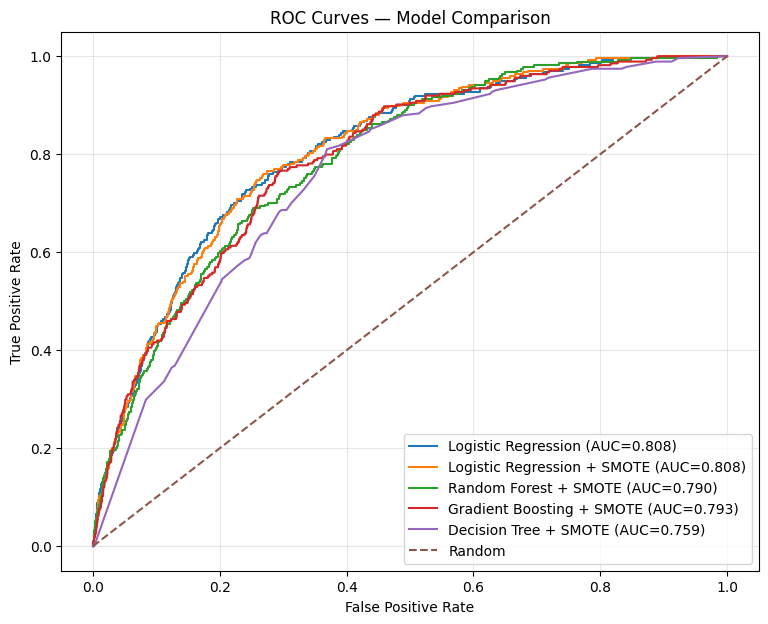

In [77]:
models = {
    "Logistic Regression": baseline_lr,
    "Logistic Regression + SMOTE": smote_lr,
    "Random Forest + SMOTE": rf,
    "Gradient Boosting + SMOTE": gb,
    "Decision Tree + SMOTE": dt
}

plt.figure(figsize=(9, 7))

for name, model in models.items():

    y_prob = model.predict_proba(
        X_test_pca_df
    )[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

PRECISION-RECALL CURVES

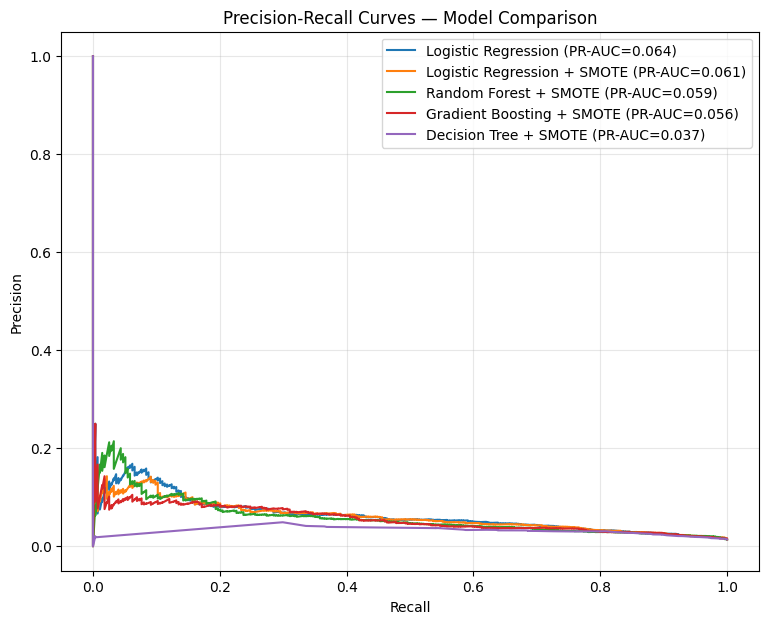

In [78]:
plt.figure(figsize=(9, 7))

for name, model in models.items():

    y_prob = model.predict_proba(
        X_test_pca_df
    )[:, 1]

    precision, recall, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    ap = average_precision_score(
        y_test,
        y_prob
    )

    plt.plot(
        recall,
        precision,
        label=f"{name} (PR-AUC={ap:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — Model Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

ENSEMBLE

In [79]:
voting_model = VotingClassifier(
    estimators=[
        ("lr", smote_lr),
        ("rf", rf),
        ("gb", gb)
    ],
    voting="soft"
)

voting_model.fit(
    X_train_smote,
    y_train_smote
)

ensemble_prob = voting_model.predict_proba(
    X_test_pca_df
)[:, 1]

print("Ensemble ROC-AUC:",
      roc_auc_score(y_test, ensemble_prob))

print("Ensemble PR-AUC:",
      average_precision_score(y_test, ensemble_prob))

Ensemble ROC-AUC: 0.808760691931645
Ensemble PR-AUC: 0.0735908270761004


THRESHOLD OPTIMIZATION

In [81]:
thresholds = np.arange(0.01, 0.51, 0.01)

threshold_results = []

for threshold in thresholds:

    y_pred = (ensemble_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "F1": f1_score(
            y_test, y_pred, zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

display(
    threshold_df.sort_values(
        "F1",
        ascending=False
    ).head(10)
)

,Threshold,Precision,Recall,F1
49,0.50,0.038393,0.711679,0.072856
48,0.49,0.037811,0.726277,0.071880
47,0.48,0.036766,0.733577,0.070023
46,0.47,0.035790,0.737226,0.068266
45,0.46,0.034713,0.740876,0.066318
44,0.45,0.034460,0.759124,0.065927
43,0.44,0.033776,0.770073,0.064714
42,0.43,0.033158,0.781022,0.063615
41,0.42,0.032620,0.795620,0.062671
40,0.41,0.032272,0.813869,0.062082


FINAL MODEL EVALUATION

In [83]:
FINAL_THRESHOLD = 0.50

# Final predictions
y_pred_final = (
    ensemble_prob >= FINAL_THRESHOLD
).astype(int)

# Calculate metrics directly
final_accuracy = accuracy_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final, zero_division=0)
final_recall = recall_score(y_test, y_pred_final, zero_division=0)
final_f1 = f1_score(y_test, y_pred_final, zero_division=0)

final_roc_auc = roc_auc_score(y_test, ensemble_prob)
final_pr_auc = average_precision_score(y_test, ensemble_prob)

print("FINAL MODEL: SOFT VOTING ENSEMBLE")
print("-" * 45)
print(f"Threshold : {FINAL_THRESHOLD}")
print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1        : {final_f1:.4f}")
print(f"ROC-AUC   : {final_roc_auc:.4f}")
print(f"PR-AUC    : {final_pr_auc:.4f}")

FINAL MODEL: SOFT VOTING ENSEMBLE
---------------------------------------------
Threshold : 0.5
Accuracy  : 0.7437
Precision : 0.0384
Recall    : 0.7117
F1        : 0.0729
ROC-AUC   : 0.8088
PR-AUC    : 0.0736


In [84]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_final)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[14204  4884]
 [   79   195]]


ROC CURVE

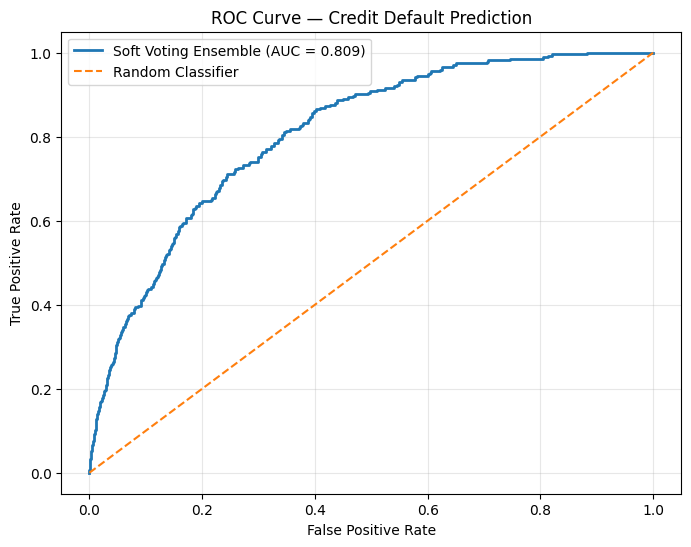

In [85]:
fpr, tpr, _ = roc_curve(y_test, ensemble_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Soft Voting Ensemble (AUC = {final_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Credit Default Prediction")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

PRECISION-RECALL CURVE

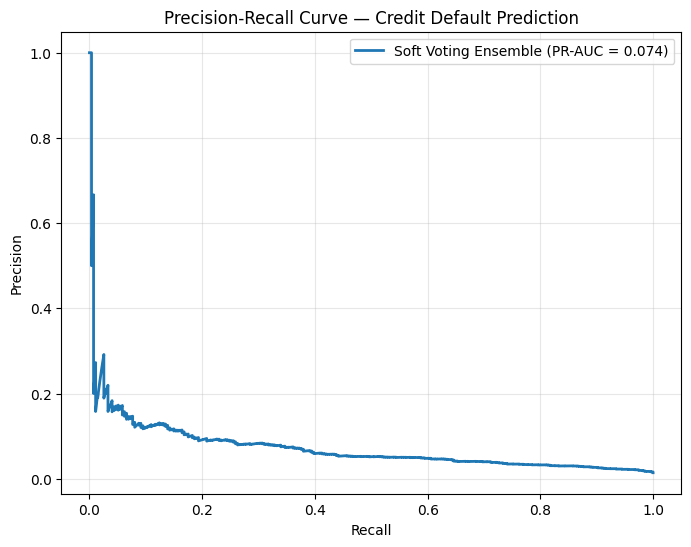

In [86]:
precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    ensemble_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label=f"Soft Voting Ensemble (PR-AUC = {final_pr_auc:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Credit Default Prediction")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

CONFUSION MATRIX

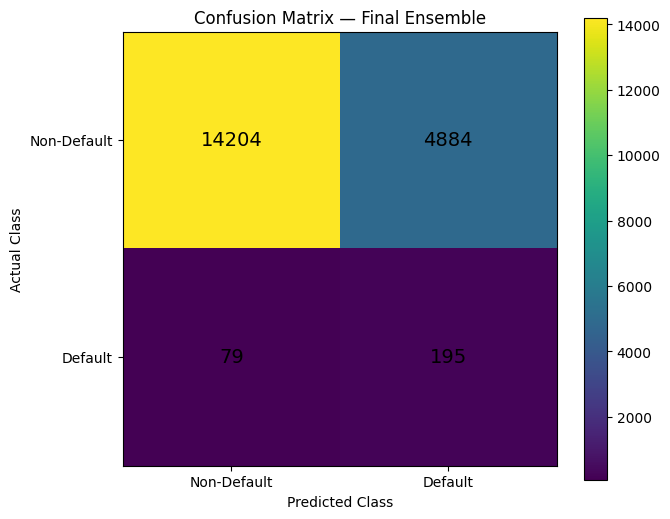

In [87]:
plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.title("Confusion Matrix — Final Ensemble")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks([0, 1], ["Non-Default", "Default"])
plt.yticks([0, 1], ["Non-Default", "Default"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=14
        )

plt.colorbar()
plt.show()